## Data Loading

In [1]:
import pandas as pd
import matplotlib.pylab as plt
netflix = pd.read_csv("Data/netflix.csv")
disney = pd.read_csv("Data/disney.csv")
amazon = pd.read_csv("Data/amazon.csv")

## Cross Platform Comparison

In [3]:
netflix['platform'] = 'Netflix'
disney['platform'] = 'Disney'
amazon['platform'] = 'Amazon'
cross_platform = pd.concat([netflix,disney,amazon],ignore_index=True)
cross_platform = cross_platform.dropna(subset=['date_added'])
cross_platform = cross_platform.drop_duplicates()
cross_platform['date_added'] = pd.to_datetime(cross_platform['date_added'].str.strip())
cross_platform['date_added'] = cross_platform['date_added'].dt.year

## Cross Platform Realses Over Year

<Axes: title={'center': 'Cross Platform Realses Over Year'}, xlabel='Years', ylabel='Relases'>

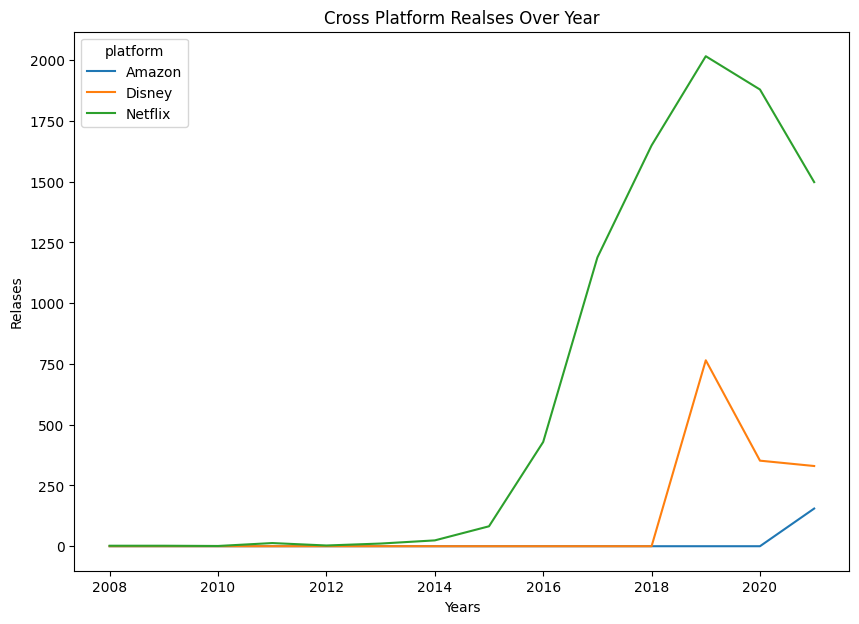

In [4]:
m = cross_platform.groupby(['platform','date_added']).size().unstack(fill_value=0,level=0)
m.plot(figsize=(10,7),title="Cross Platform Realses Over Year",xlabel="Years",ylabel="Relases")

## Cross Platform Movie Realses Over Years

<Axes: title={'center': 'Cross Platform Movie Realses Over Years'}, xlabel='Years', ylabel='Number of Movies'>

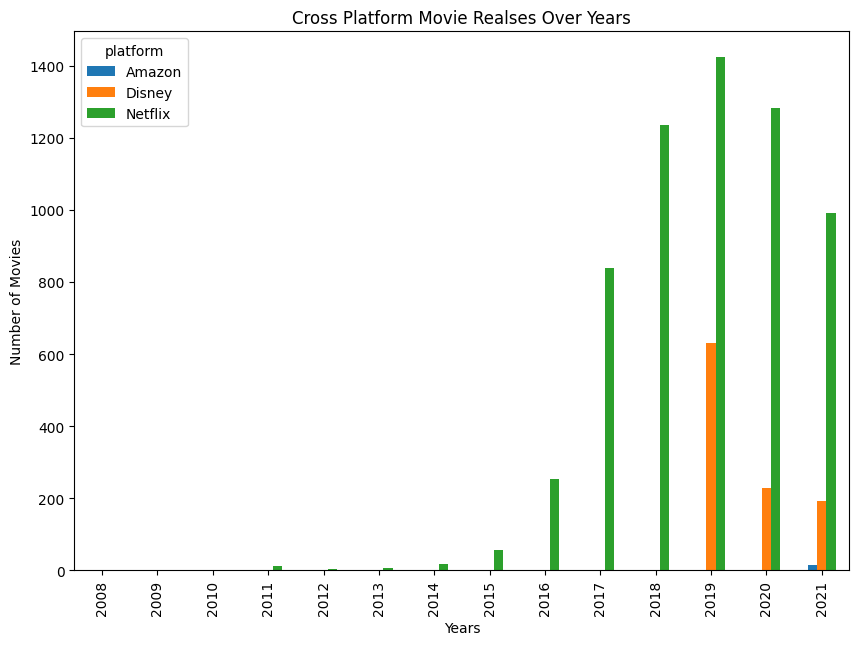

In [5]:
cross_mov = cross_platform[cross_platform['type']=='Movie']
mov = cross_mov.groupby(['platform','date_added']).size().unstack(level=0,fill_value=0)
mov.plot(kind='bar',figsize=(10,7),xlabel='Years',ylabel='Number of Movies',title='Cross Platform Movie Realses Over Years')

## Cross Platform Movie Realses Vs Tv Shows Over Years

<Axes: title={'center': 'Cross Platform TV Shows Realses Over Years'}, xlabel='Years', ylabel='Number of TV Shows'>

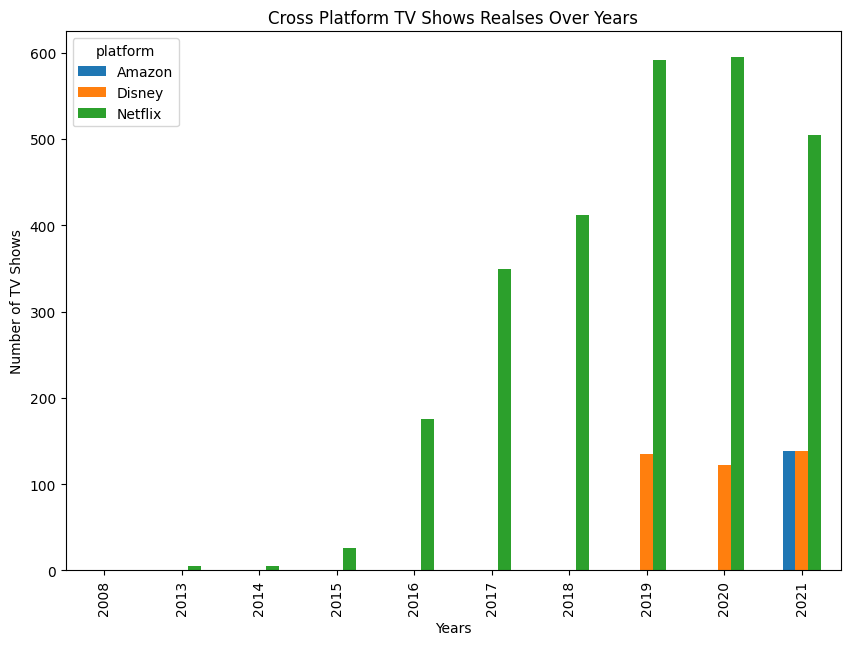

In [6]:
cross_mov = cross_platform[cross_platform['type']=='TV Show']
show = cross_mov.groupby(['platform','date_added']).size().unstack(level=0,fill_value=0)
show.plot(kind='bar',figsize=(10,7),xlabel='Years',ylabel='Number of TV Shows',title='Cross Platform TV Shows Realses Over Years')

## Cross Platform Relases By Rating

<Axes: ylabel='rating'>

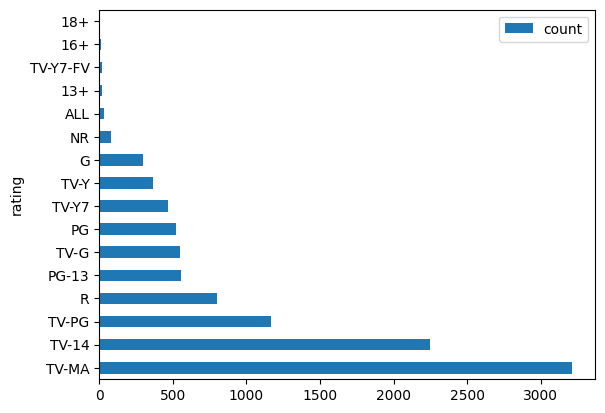

In [7]:
rat = pd.DataFrame(cross_platform['rating'].value_counts())
rat = rat.iloc[:16]
rat.plot(kind='barh')

## Cross Platform Relases By Country

<Axes: ylabel='Country Vise Realses'>

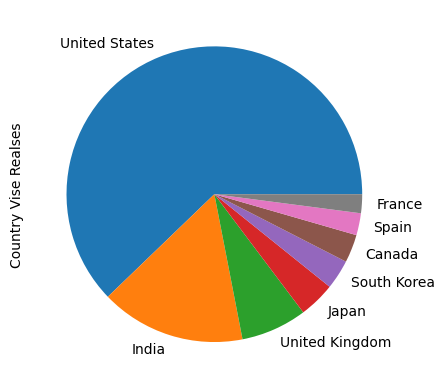

In [232]:
cross_platform['country'].value_counts().head(8).plot(kind='pie',ylabel='Country Vise Realses')

### Insights:

1. Average movie duration is consistent across platforms.
2. United Sates Relases more content than other countries followed by india
3. All platforms are realsing TV-MA rated content followed by TV-14

# Netflix Data Analaysis

### Netflix Data Cleaning

In [233]:
net = netflix.drop(columns=['cast','description','director','rating','listed_in'])
net = net.dropna()
net = net.drop_duplicates()
net['date_added'] = pd.to_datetime(net['date_added'].str.strip())
net['date_added'] = net['date_added'].dt.year
net.rename(columns={'date_added':'added_year'},inplace=True)

## Netflix Movies Vs Tv Shows Realses

<Axes: title={'center': 'Movies Vs Tv Shows - Netflix'}, xlabel='type'>

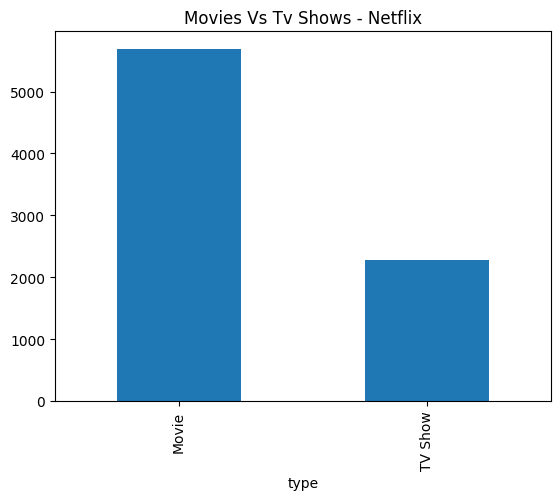

In [234]:
net['type'].value_counts().plot(kind='bar',title="Movies Vs Tv Shows - Netflix")

## Netflix Movies Vs Tv Shows Over Time

<Axes: title={'center': 'Movies vs Tv Shows Over Time - Netflix'}, xlabel='Years'>

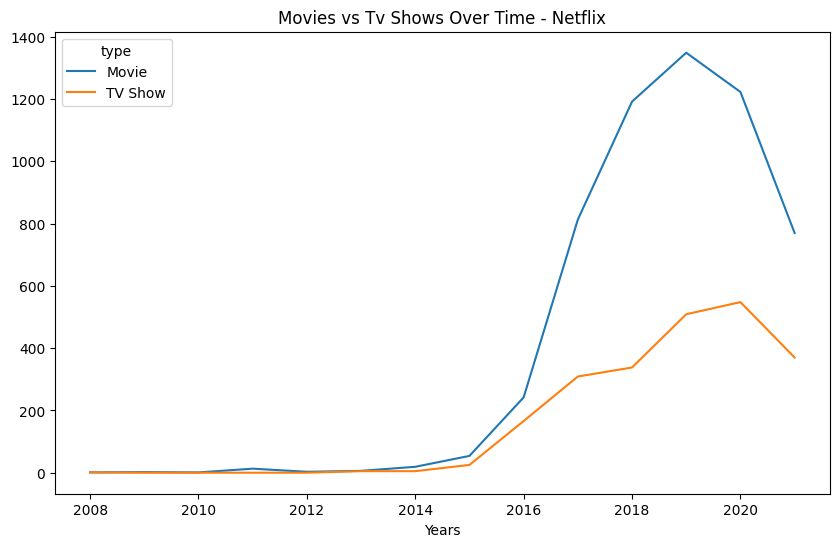

In [246]:
content_count = net.groupby(['type','added_year']).size().unstack(fill_value=0,level=0)

content_count.plot(title='Movies vs Tv Shows Over Time - Netflix',figsize=(10,6),xlabel='Years')

## Netflix Movie Duration Over Years

<Axes: title={'center': 'Average Moive Duration Over Years - Netflix'}, xlabel='Years', ylabel='Duration(min)'>

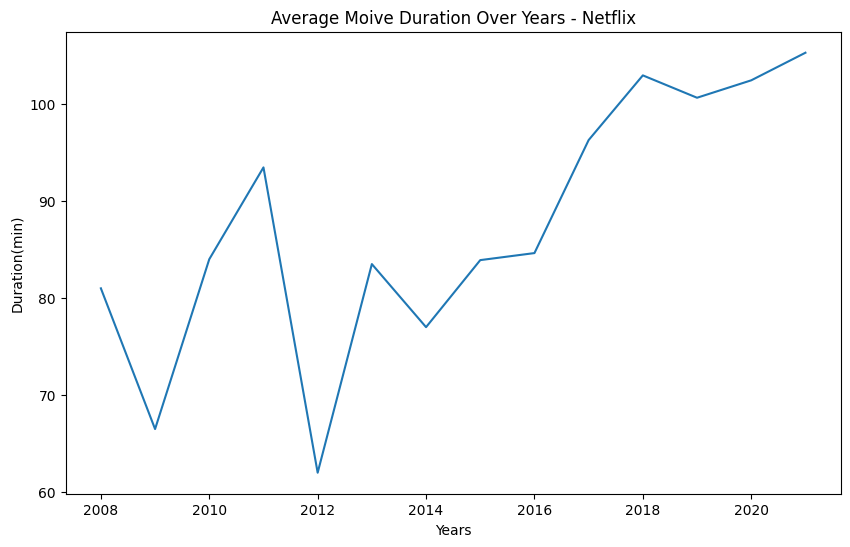

In [247]:
net_movies = net[net['type']=='Movie'].copy()
net_movies['duration'] = net_movies['duration'].str.replace(' min','').astype(int)
mov_dur = net_movies.groupby('added_year')['duration'].mean()
mov_dur.plot(title='Average Moive Duration Over Years - Netflix', xlabel='Years',ylabel='Duration(min)',figsize=(10,6))

## Netflix Tv Shows Seasons Over Year

<Axes: title={'center': 'Average Tv Shows Duration Over Years - Netflix '}, xlabel='Years', ylabel='Seasons'>

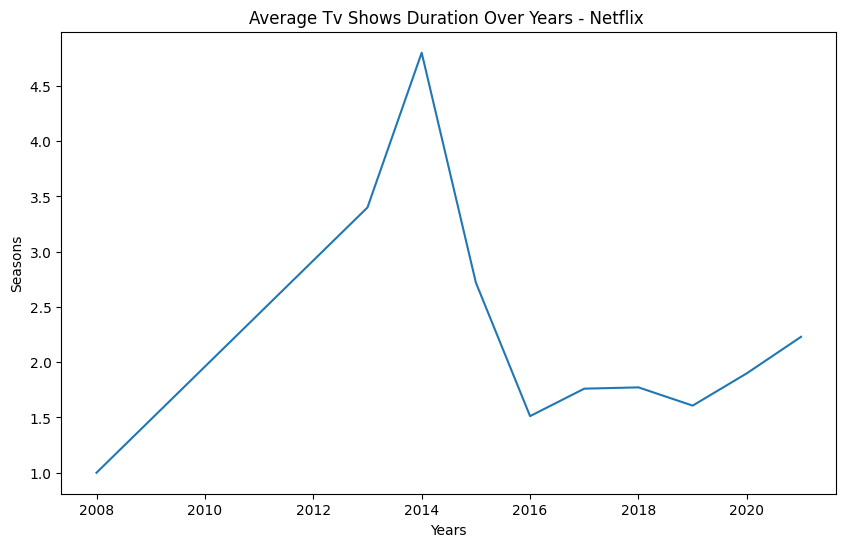

In [248]:
net_shows = net[net['type']=='TV Show'].copy()
net_shows['duration'] = net_shows['duration'].str.split(' ').str[0].astype(int)
seasons = net_shows.groupby('added_year')['duration'].mean()
seasons.plot(title='Average Tv Shows Duration Over Years - Netflix ',xlabel='Years',ylabel='Seasons',figsize=(10,6))

## Netlfix Realses By Country

<Axes: title={'center': 'Movies Over Countries - Netflix'}, xlabel='country'>

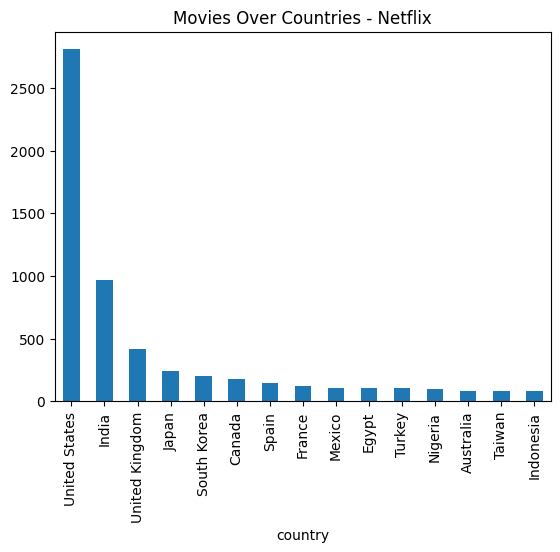

In [249]:
net['country'].value_counts().head(15).plot(kind='bar',title="Movies Over Countries - Netflix")

## Insights:

1. Movies Realses dominate tv shows in netflix
2. Duration of movies gradually increasing over time
3. Tv-shows gradually decreased over time peaked at 2013-2015

# Disney Data Analysis

### Disney Data Cleaning

In [250]:
dis = disney.drop(columns=['cast','description','director','rating','listed_in'])
dis = dis.dropna()
dis = dis.drop_duplicates()
dis['date_added'] = pd.to_datetime(dis['date_added'].str.strip())
dis['date_added'] = dis['date_added'].dt.year
dis.rename(columns={'date_added':'added_year'},inplace=True)

## Disney Movies and Tv Shows Relises

<Axes: title={'center': 'Movies Vs Tv Shows - Disney'}, xlabel='type'>

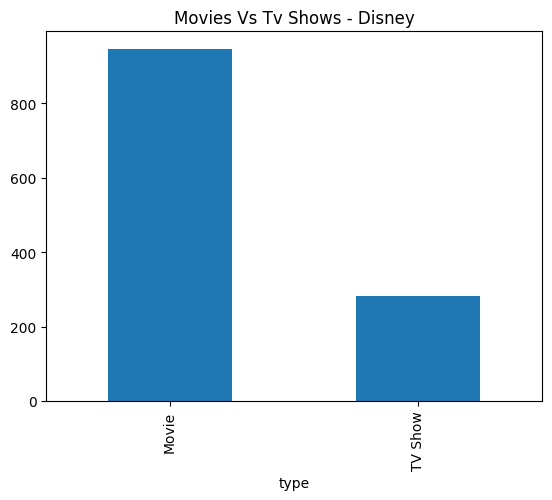

In [251]:
dis['type'].value_counts().plot(kind='bar',title="Movies Vs Tv Shows - Disney")

## Disney Movies Vs Tv Shows Over Time

<Axes: title={'center': 'Movies vs Tv Shows Over Time - Disney'}, xlabel='Years'>

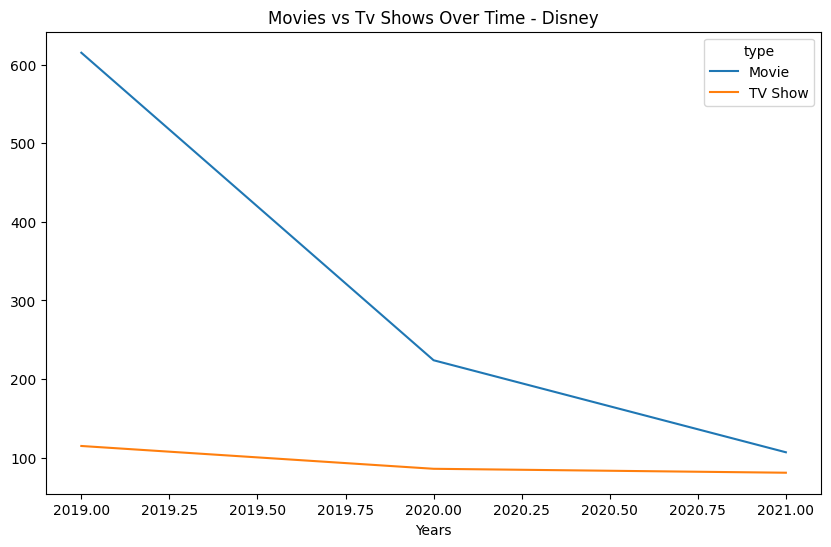

In [257]:
content_count = dis.groupby(['type','added_year']).size().unstack(fill_value=0,level=0)

content_count.plot(title='Movies vs Tv Shows Over Time - Disney',figsize=(10,6),xlabel='Years')

## Disney Movie Duration Over Years

<Axes: title={'center': 'Average Moive Duration Over Years - Disney'}, xlabel='Years', ylabel='Duration(min)'>

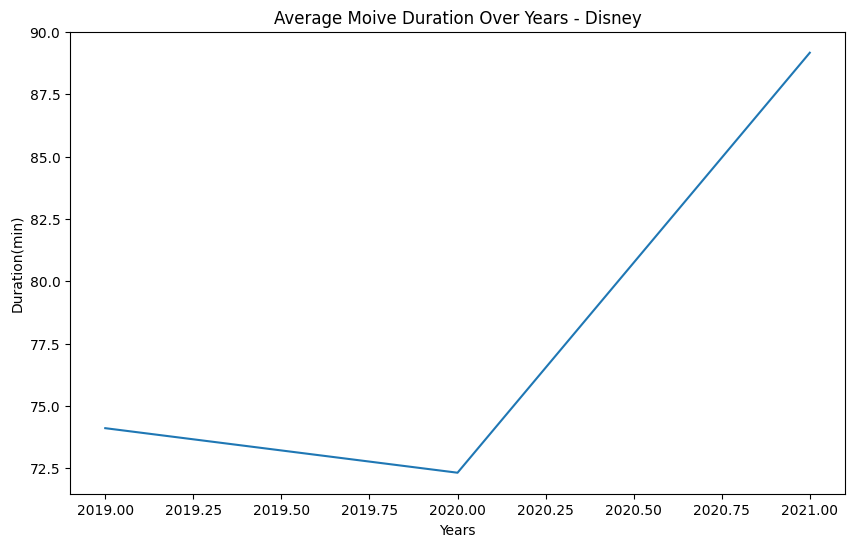

In [258]:
dis_movies = dis[dis['type']=='Movie'].copy()
dis_movies['duration'] = dis_movies['duration'].str.replace(' min','').astype(int)
mov_dur = dis_movies.groupby('added_year')['duration'].mean()
mov_dur.plot(title='Average Moive Duration Over Years - Disney', xlabel='Years',ylabel='Duration(min)',figsize=(10,6))

## Disney Tv Shows Duration Over Years

<Axes: title={'center': 'Average Tv Shows Duration Over Years - Disney '}, xlabel='Years', ylabel='Seasons'>

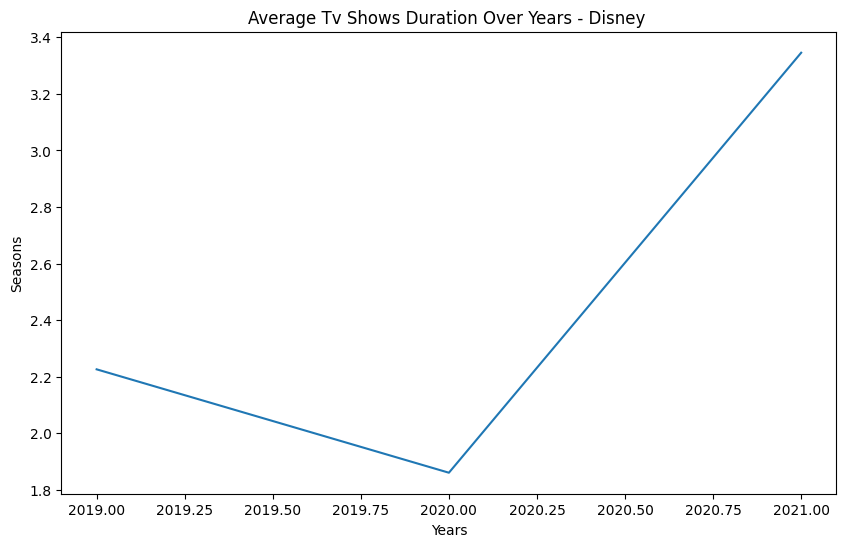

In [259]:
dis_shows = dis[dis['type']=='TV Show'].copy()
dis_shows['duration'] = dis_shows['duration'].str.split(' ').str[0].astype(int)
seasons = dis_shows.groupby('added_year')['duration'].mean()
seasons.plot(title='Average Tv Shows Duration Over Years - Disney ',xlabel='Years',ylabel='Seasons',figsize=(10,6))

## insights:
1. Movie Realses decreased over time compared tv shows in disney
2. Average Duration of movies and tv shows exponentially increased from 2020

## Amazon Data Analysis

In [260]:
amz = amazon.drop(columns=['cast','description','director','rating','listed_in'])
amz = amz.dropna(subset='date_added')
amz = amz.drop_duplicates()
amz['date_added'] = pd.to_datetime(amz['date_added'].str.strip())
amz['date_added'] = amz['date_added'].dt.year
amz.rename(columns={'date_added':'added_year'},inplace=True)

## Amazon Movies Vs Tv Shows Relises

<Axes: title={'center': 'Movies Vs Tv Shows - Amazon'}, xlabel='type'>

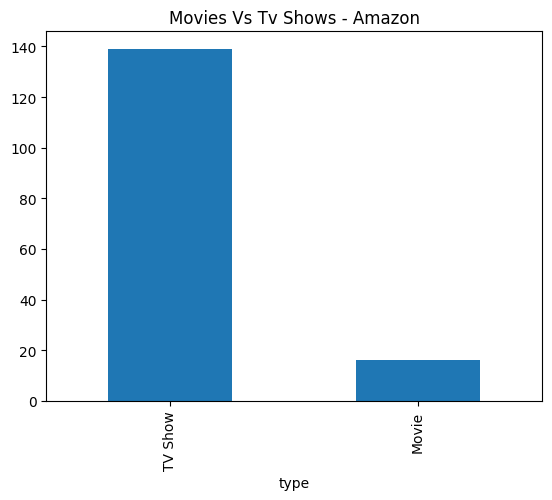

In [261]:
amz['type'].value_counts().plot(kind='bar',title="Movies Vs Tv Shows - Amazon")


## Key Insights

1. Movies are major form of content in every platform.
2. Netflix has a significantly larger content library compared to Amazon and Disney+, indicating a more aggressive content acquisition strategy.
3. Content growth is clearly visible only in Netflix due to better data availability.
4. Average movie duration is consistent across platforms.
5. Data limitations exist in Amazon dataset, affecting time-based analysis.
6. United Sates releases more content than any country followed by india
7. Netflix shows clear growth trends over time, unlike Amazon due to missing date data.
8. TV shows generally have multiple seasons, but their count is significantly lower than movies across platforms.